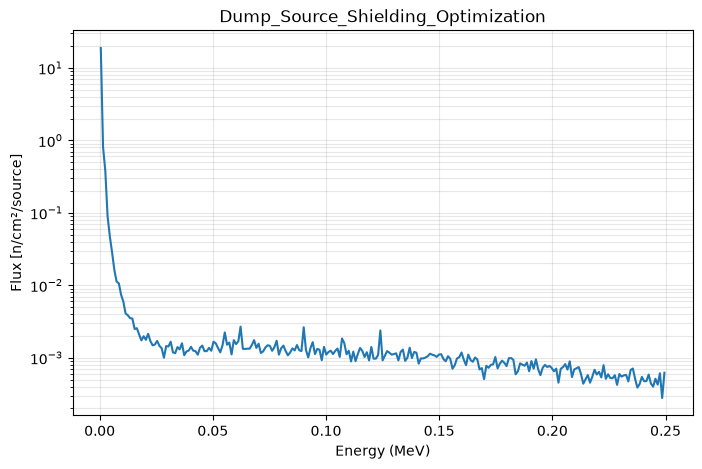

In [1]:
import numpy as np
import matplotlib.pyplot as plt

path = '../data/raw/spectra/Dump_Source_Shielding_Optimization.txt'
lower, upper, flux, err = np.loadtxt(path, skiprows=2, unpack=True)
E = (lower + upper) / 2

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(E, flux)
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel('Flux [n/cm²/source]')
ax.set_title('Dump_Source_Shielding_Optimization')
ax.grid(True, which='both', alpha=0.3)
plt.show()

flux[0] = 1.0


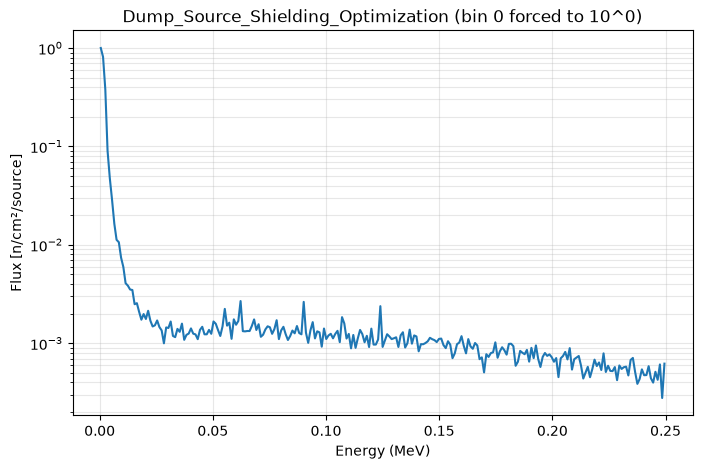

In [2]:
# (A) Manually set the first bin to 10^0
flux[0] = 10**0
print('flux[0] =', flux[0])

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(E, flux)
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel('Flux [n/cm²/source]')
ax.set_title('Dump_Source_Shielding_Optimization (bin 0 forced to 10^0)')
ax.grid(True, which='both', alpha=0.3)
plt.show()

In [3]:
# (B) 2D dose map — Steel + Concrete two-layer shielding
# Layer 1: Steel (k100s2_v1, a-factor only) | Layer 2: Concrete (transfer_concrete45_mlp, TrackNet10 source)
import sys, json, os
sys.path.insert(0, '..')

from scripts.inference.single_layer import load_model, compute_dose
from scripts.inference.multilayer import predict_tracknet_source

registry = json.load(open('../models/registry.json'))
model_v1       = load_model('../' + registry['primary']['k100s2_v1']['pkl'])
model_transfer = load_model('../' + registry['experimental']['transfer_concrete45_mlp']['pkl'])

steel_t    = np.arange(10, 101, 5)   # 10-100 cm
concrete_t = np.arange(10, 151, 5)   # 10-150 cm

CACHE = 'dosemap_cache/steel_concrete.npy'
if os.path.exists(CACHE):
    dose_map = np.load(CACHE)
    print('loaded from cache:', CACHE)
else:
    dose_map = np.zeros((len(steel_t), len(concrete_t)))
    for i, ts in enumerate(steel_t):
        for j, tc in enumerate(concrete_t):
            pred = predict_tracknet_source(model_v1, model_transfer, 'Steel', ts, 'Concrete', tc)
            dose_map[i, j] = compute_dose(pred) * 9.78e7
    os.makedirs('dosemap_cache', exist_ok=True)
    np.save(CACHE, dose_map)
    print('computed and saved to cache:', CACHE)

print('dose_map shape:', dose_map.shape)

computed and saved to cache: dosemap_cache/steel_concrete.npy
dose_map shape: (19, 29)


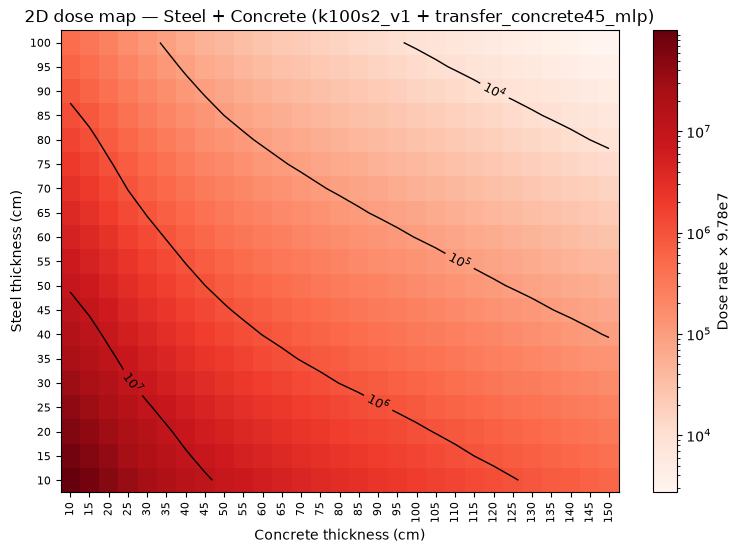

In [4]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(9, 6))
pcm = ax.pcolormesh(concrete_t, steel_t, dose_map, shading='auto',
                     norm=LogNorm(vmin=dose_map[dose_map > 0].min(), vmax=dose_map.max()),
                     cmap='Reds')
fig.colorbar(pcm, ax=ax, label='Dose rate × 9.78e7')

levels = [1e4, 1e5, 1e6, 1e7]
cs = ax.contour(concrete_t, steel_t, dose_map, levels=levels,
                 colors='black', linewidths=1.0)
ax.clabel(cs, fmt=lambda v: f'$10^{{{int(np.log10(v))}}}$', fontsize=9)

ax.set_xticks(concrete_t)
ax.set_yticks(steel_t)
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.tick_params(axis='y', labelsize=8)

ax.set_xlabel('Concrete thickness (cm)')
ax.set_ylabel('Steel thickness (cm)')
ax.set_title('2D dose map — Steel + Concrete (k100s2_v1 + transfer_concrete45_mlp)')
plt.show()

In [5]:
# Steel + Poly (BPE) — same protocol as Steel + Concrete above
bpe_t = np.arange(10, 151, 5)  # same 10-150 cm range

CACHE_POLY = 'dosemap_cache/steel_poly.npy'
if os.path.exists(CACHE_POLY):
    dose_map_poly = np.load(CACHE_POLY)
    print('loaded from cache:', CACHE_POLY)
else:
    dose_map_poly = np.zeros((len(steel_t), len(bpe_t)))
    for i, ts in enumerate(steel_t):
        for j, tb in enumerate(bpe_t):
            pred = predict_tracknet_source(model_v1, model_transfer, 'Steel', ts, 'BPE', tb)
            dose_map_poly[i, j] = compute_dose(pred) * 9.78e7
    np.save(CACHE_POLY, dose_map_poly)
    print('computed and saved to cache:', CACHE_POLY)

print('dose_map_poly shape:', dose_map_poly.shape)

computed and saved to cache: dosemap_cache/steel_poly.npy
dose_map_poly shape: (19, 29)


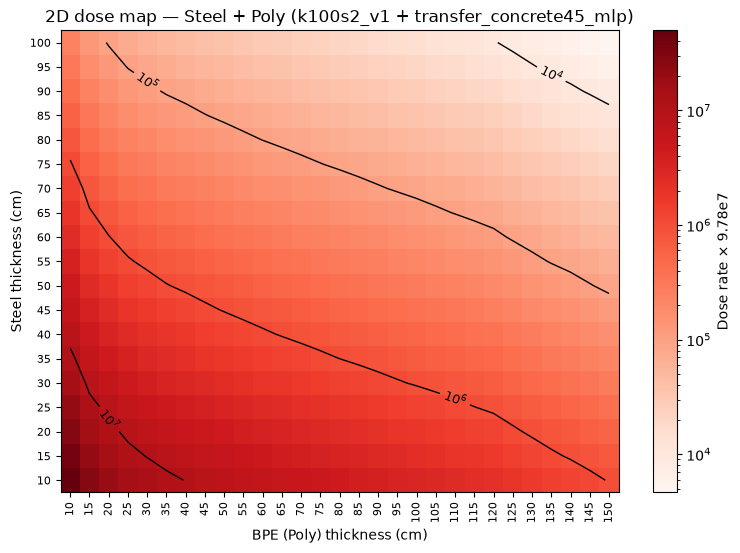

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
pcm = ax.pcolormesh(bpe_t, steel_t, dose_map_poly, shading='auto',
                     norm=LogNorm(vmin=dose_map_poly[dose_map_poly > 0].min(), vmax=dose_map_poly.max()),
                     cmap='Reds')
fig.colorbar(pcm, ax=ax, label='Dose rate × 9.78e7')

cs = ax.contour(bpe_t, steel_t, dose_map_poly, levels=levels, colors='black', linewidths=1.0)
ax.clabel(cs, fmt=lambda v: f'$10^{{{int(np.log10(v))}}}$', fontsize=9)

ax.set_xticks(bpe_t)
ax.set_yticks(steel_t)
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.tick_params(axis='y', labelsize=8)

ax.set_xlabel('BPE (Poly) thickness (cm)')
ax.set_ylabel('Steel thickness (cm)')
ax.set_title('2D dose map — Steel + Poly (k100s2_v1 + transfer_concrete45_mlp)')
plt.show()

In [7]:
# 3-layer: Steel (swept) -> Concrete (swept) -> BPE/Poly fixed at 20 cm
# Uses the 3-layer protocol (scripts/inference/three_layer.py).
# Approach 1 (amplitude-only, TrackNet10 fed to both layer 2 and layer 3) —
# the direct 3-layer extension of the predict_tracknet_source method used above.
# (Note: the earlier PHITS validation showed Approach 4, full actual-output
# chaining, can do better in some cases — say the word if you want that instead.)
from scripts.inference.three_layer import predict_3layer

POLY_FIXED = 20  # cm

CACHE_3L = 'dosemap_cache/steel_concrete_poly20_3layer.npy'
if os.path.exists(CACHE_3L):
    dose_map_3l = np.load(CACHE_3L)
    print('loaded from cache:', CACHE_3L)
else:
    dose_map_3l = np.zeros((len(steel_t), len(concrete_t)))
    for i, ts in enumerate(steel_t):
        for j, tc in enumerate(concrete_t):
            pred = predict_3layer(
                model_v1, model_transfer,
                'Steel', ts, 'Concrete', tc, 'BPE', POLY_FIXED,
                l2_source='tracknet10', l3_source='tracknet10',
            )
            dose_map_3l[i, j] = compute_dose(pred) * 9.78e7
    np.save(CACHE_3L, dose_map_3l)
    print('computed and saved to cache:', CACHE_3L)

print('dose_map_3l shape:', dose_map_3l.shape)

computed and saved to cache: dosemap_cache/steel_concrete_poly20_3layer.npy
dose_map_3l shape: (19, 29)


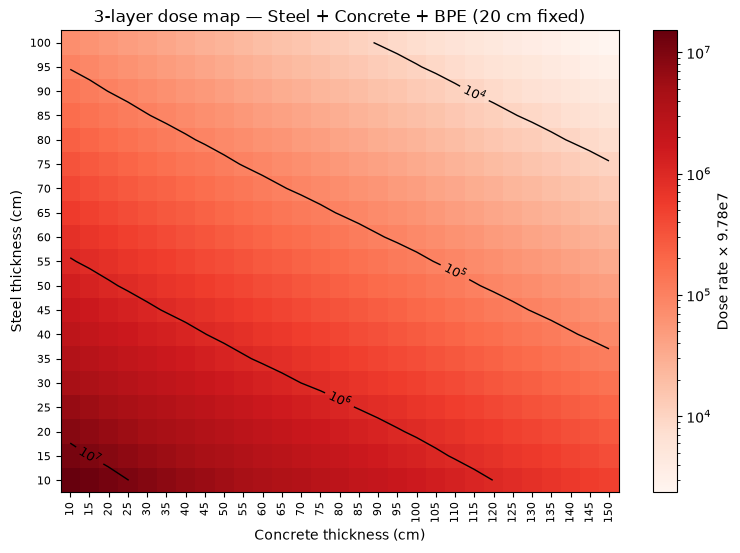

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
pcm = ax.pcolormesh(concrete_t, steel_t, dose_map_3l, shading='auto',
                     norm=LogNorm(vmin=dose_map_3l[dose_map_3l > 0].min(), vmax=dose_map_3l.max()),
                     cmap='Reds')
fig.colorbar(pcm, ax=ax, label='Dose rate × 9.78e7')

cs = ax.contour(concrete_t, steel_t, dose_map_3l, levels=levels, colors='black', linewidths=1.0)
ax.clabel(cs, fmt=lambda v: f'$10^{{{int(np.log10(v))}}}$', fontsize=9)

ax.set_xticks(concrete_t)
ax.set_yticks(steel_t)
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.tick_params(axis='y', labelsize=8)

ax.set_xlabel('Concrete thickness (cm)')
ax.set_ylabel('Steel thickness (cm)')
ax.set_title(f'3-layer dose map — Steel + Concrete + BPE ({POLY_FIXED} cm fixed)')
plt.show()